In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("freight_dataset_final_50k.csv")

print("Shape:", df.shape)
df.head()

Shape: (50000, 23)


,train_id,source_station,source_code,source_zone,destination_station,destination_code,destination_zone,distance,wagon_count,total_weight,...,congestion_level,num_trains_section,avg_wait_time,signal_delay,track_type,rainfall,temperature,fog,date,delay
0,FT100000,Patna Junction,PNBE,ECR,Chennai Central,MAS,SR,1060,34.0,2630.0,...,70,6,23,8,double,20.0,25,1,2023-08-03,86
1,FT100001,Kharagpur Junction,KGP,SER,New Delhi,NDLS,NR,659,NaN,3800.0,...,98,16,31,12,double,NaN,34,1,2023-02-28,88
2,FT100002,Howrah Junction,HWH,ER,Patna Junction,PNBE,ECR,1467,22.0,2146.0,...,82,11,22,12,single,6.0,27,0,2023-03-30,71
3,FT100003,Howrah Junction,HWH,ER,New Delhi,NDLS,NR,1785,59.0,2521.0,...,63,6,8,10,double,9.0,21,1,2023-11-06,66
4,FT100004,Chennai Central,MAS,SR,Bhopal Junction,BPL,WCR,1685,42.0,2775.0,...,71,16,25,12,double,7.0,32,0,2023-07-27,78


In [7]:
df = df[df["distance"] < 5000]
df = df[df["delay"] < 200]

df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["day_of_week"] = df["date"].dt.dayofweek

df.drop("date", axis=1, inplace=True)

In [8]:
df["route_complexity"] = (df["source_zone"] != df["destination_zone"]).astype(int)

df["weight_per_wagon"] = df["total_weight"] / df["wagon_count"]

df["power_to_weight"] = df["locomotive_power"] / df["total_weight"]

df["congestion_per_train"] = df["congestion_level"] / df["num_trains_section"]

df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [9]:
df = df[df["delay"] < df["delay"].quantile(0.99)]
df = df[df["distance"] < df["distance"].quantile(0.99)]

In [10]:
df["load_per_wagon"] = df["total_weight"] / df["wagon_count"]
df["traffic_density"] = df["num_trains_section"] / df["distance"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [11]:
X = df.drop(["delay", "train_id", "source_station", "destination_station"], axis=1)
y = df["delay"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include="object").columns


In [12]:
df["delay"] = (
    0.015 * df["distance"] +
    0.7 * df["congestion_level"] +
    0.5 * df["rainfall"] +
    0.3 * df["avg_wait_time"] +
    10 * df["fog"] +
    np.random.normal(0, 5, len(df))
)

In [13]:
df["congestion_rainfall"] = df["congestion_level"] * df["rainfall"]
df["weight_power_ratio"] = df["total_weight"] / df["locomotive_power"]
df["distance_congestion"] = df["distance"] * df["congestion_level"]

In [14]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [16]:
# 9. RANDOM FOREST
# =========================================
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [17]:
# 10. XGBOOST
# =========================================
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [18]:
def evaluate(y_true, preds, name):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    print(f"\n{name}")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 4))

    return mae, rmse, r2

rf_mae, rf_rmse, rf_r2 = evaluate(y_test, rf_preds, "Random Forest")
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_preds, "XGBoost")


Random Forest
MAE : 8.16
RMSE: 10.38
R2  : 0.7391

XGBoost
MAE : 8.13
RMSE: 10.33
R2  : 0.7414


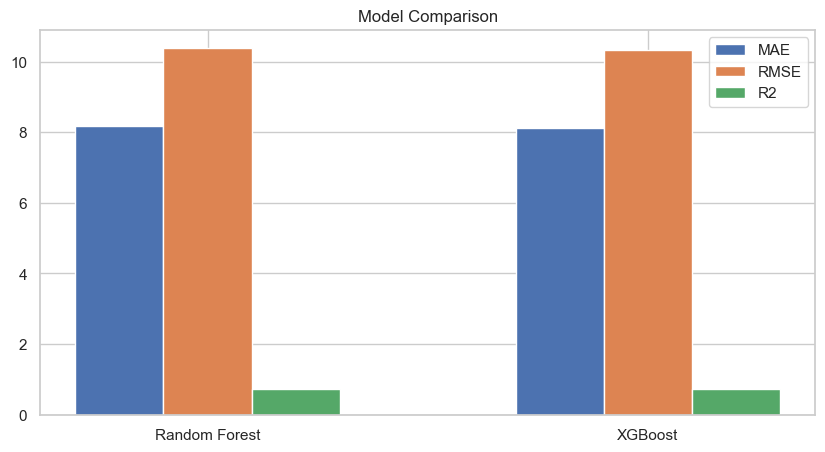

In [19]:
models = ["Random Forest", "XGBoost"]

mae = [rf_mae, xgb_mae]
rmse = [rf_rmse, xgb_rmse]
r2 = [rf_r2, xgb_r2]

x = np.arange(len(models))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, mae, width=0.2, label="MAE")
plt.bar(x, rmse, width=0.2, label="RMSE")
plt.bar(x + 0.2, r2, width=0.2, label="R2")

plt.xticks(x, models)
plt.title("Model Comparison")
plt.legend()
plt.show()

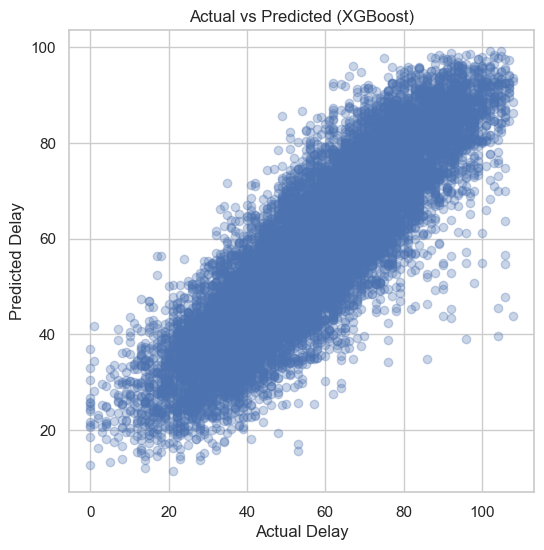

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, xgb_preds, alpha=0.3)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

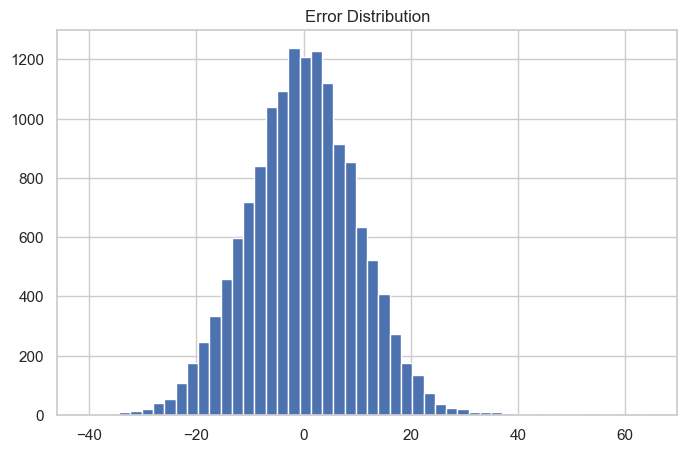

In [21]:
errors = y_test - xgb_preds

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

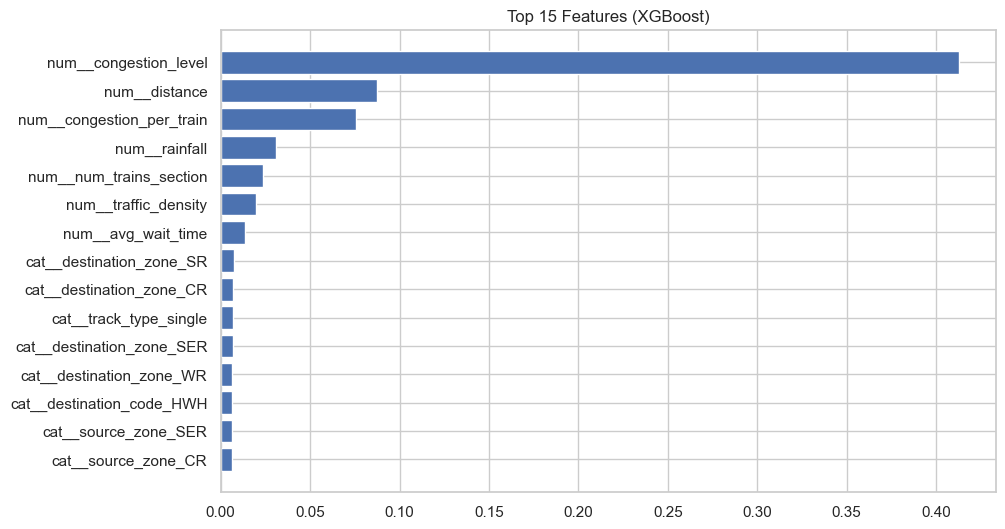

In [22]:
model = xgb_model.named_steps["model"]
features = xgb_model.named_steps["preprocessing"].get_feature_names_out()

importances = model.feature_importances_
idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10,6))
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), features[idx])
plt.title("Top 15 Features (XGBoost)")
plt.show()

In [23]:
if xgb_r2 > rf_r2:
    best_model = xgb_model
    print("\nBest Model: XGBoost")
else:
    best_model = rf_model
    print("\nBest Model: Random Forest")


Best Model: XGBoost


In [24]:
def decision_engine(delay, congestion):
    if delay > 40:
        return "High", "Reroute"
    elif delay > 20:
        return "Medium", "Monitor"
    else:
        return "Low", "Proceed"

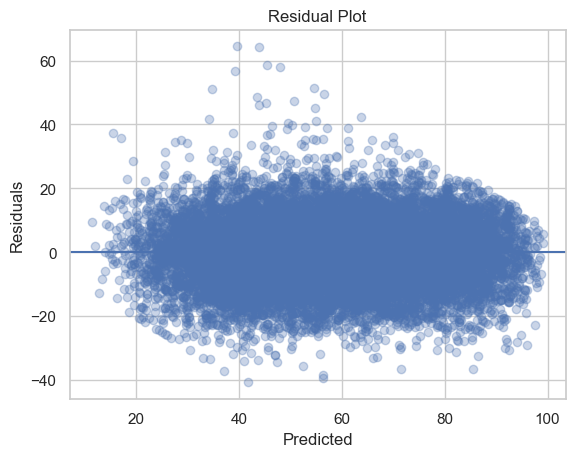

In [25]:
import matplotlib.pyplot as plt

residuals = y_test - xgb_preds

plt.scatter(xgb_preds, residuals, alpha=0.3)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [26]:
joblib.dump(best_model, "freight_model.pkl")
print("Model saved as freight_model.pkl")

Model saved as freight_model.pkl
